Processing step 1: Feature Engineering...
✔ Saved Phase 1 output: 'X_train_engineered.csv'
Processing step 2: Cluster Segmentation...
✔ Saved Phase 2 output: 'X_train_clustered.csv'

Training optimized model over pipeline infrastructure...

UPGRADED HYBRID PIPELINE PERFORMANCE EVALUATION
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      1593
           1       0.62      0.63      0.62       407

    accuracy                           0.85      2000
   macro avg       0.76      0.76      0.76      2000
weighted avg       0.85      0.85      0.85      2000

Optimized ROC-AUC Score: 0.8579



C:\Users\Pragya Tiwari\AppData\Local\Temp\ipykernel_22652\859464576.py:237: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.index, y=segment_counts.values, palette="magma")


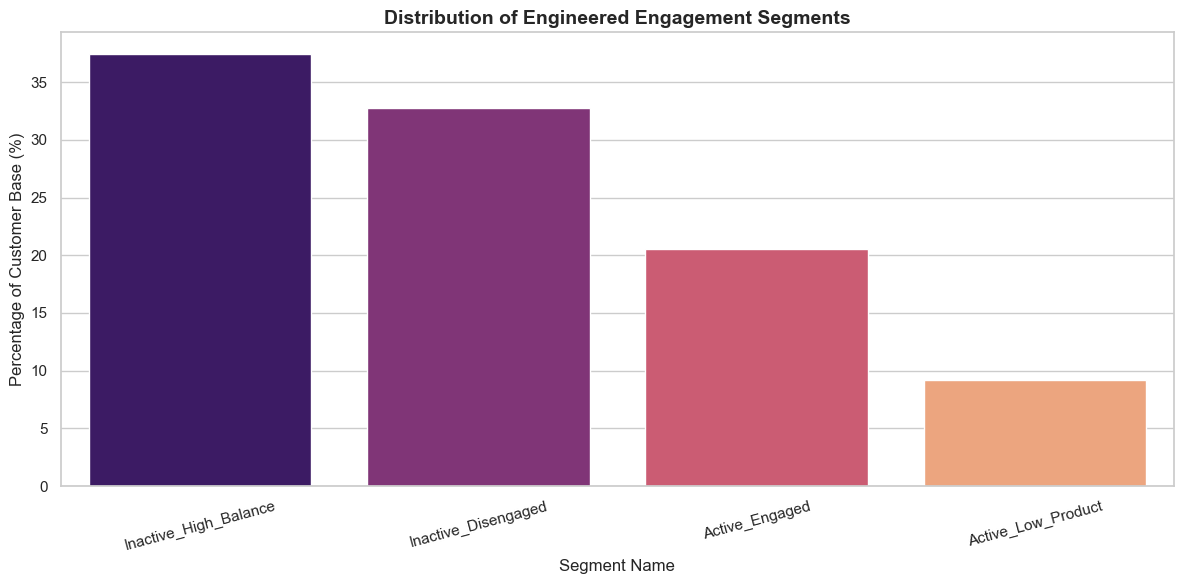

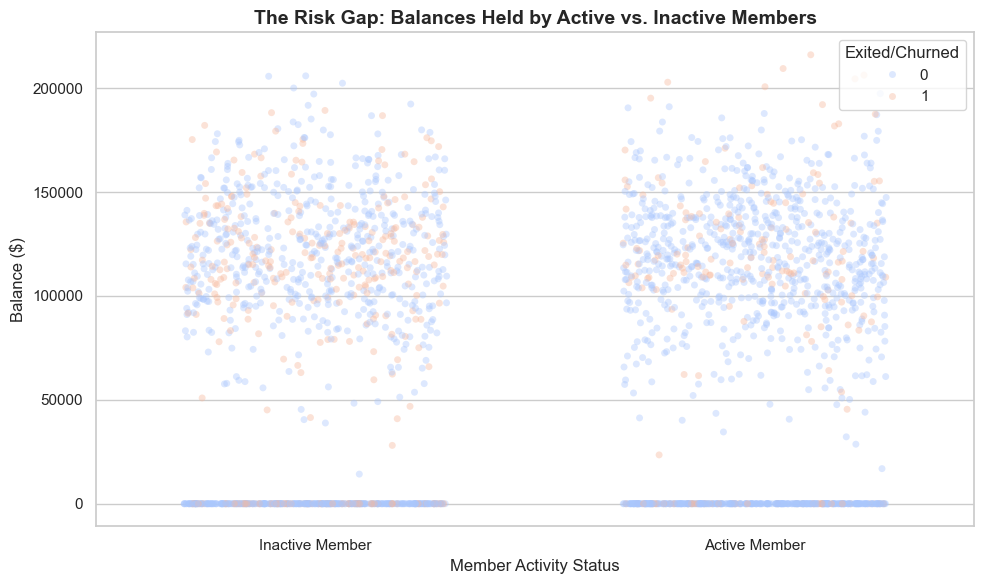

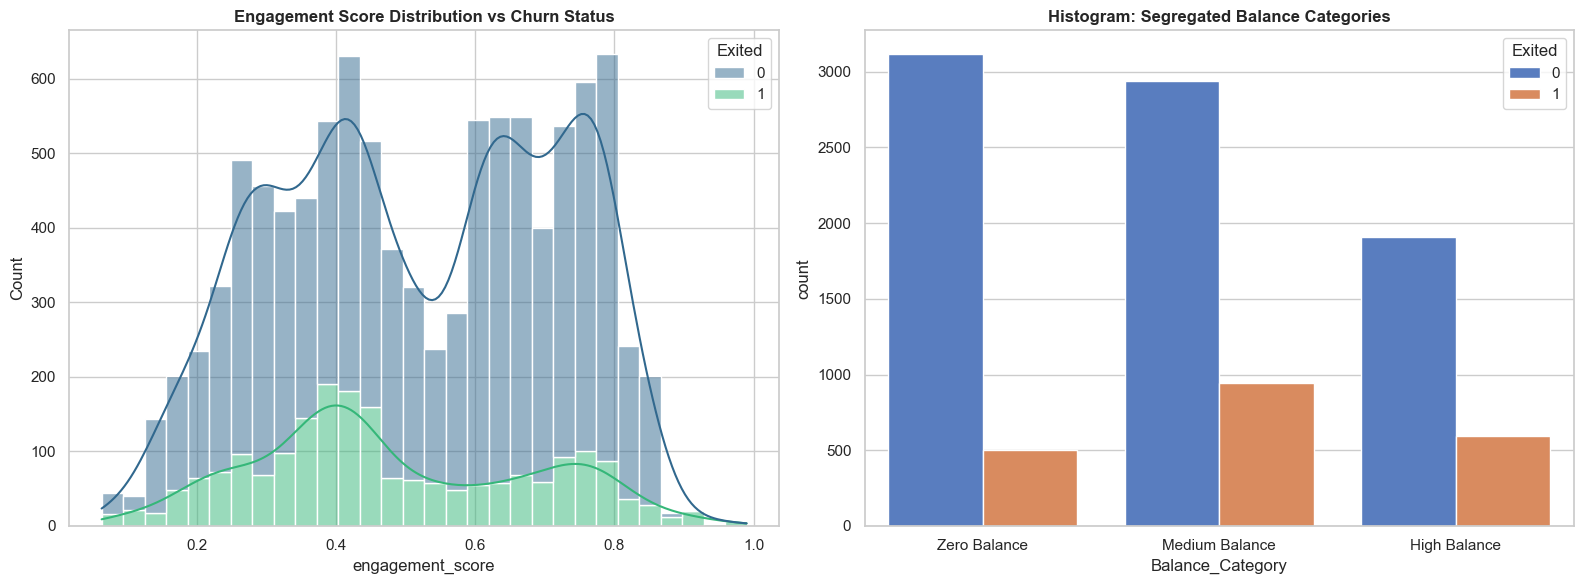

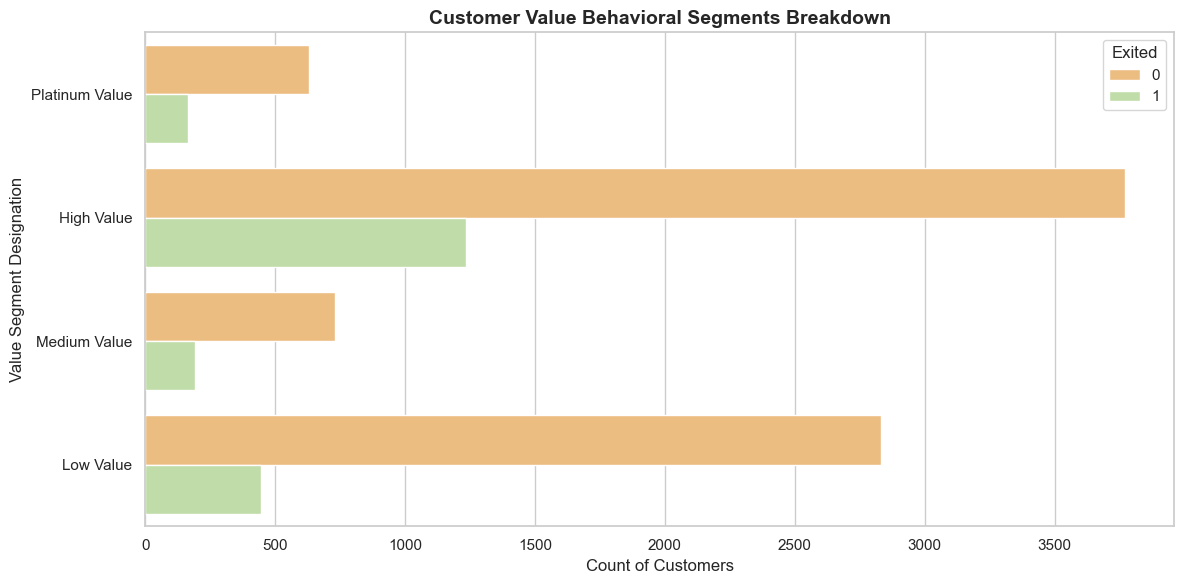

In [ ]:

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

class FeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Cleans structural schemas, encodes predictable categories,
    and constructs advanced behavioral matrices.
    """
    def __init__(self):
        self.encoded_columns_ = None

    def fit(self, X, y=None):
        X_sample = self.transform(X)
        self.encoded_columns_ = X_sample.columns
        return self

    def transform(self, X):
        X = X.copy()
        
        # Drop unique identifiers safely
        X = X.drop(columns=["CustomerId", "Surname", "Year"], errors="ignore")

        # Basic transformations & logs
        X["balance_log"] = np.log1p(X["Balance"])
        X["salary_log"] = np.log1p(X["EstimatedSalary"])
        #0-->0,100->4,1000->6,100000-->11 , reduce skewness n numeric range 
        X["product_norm"] = X["NumOfProducts"] / 4.0
        #product norm 0 to 1 range , for buyer of 1 prod,2,3,4
        
        X["tenure_norm"] = X["Tenure"] / 10.0
        #scaling downgrading range 
        X["card_flag"] = X["HasCrCard"].astype(int)
        #convert t int32
        X["active_flag"] = X["IsActiveMember"].astype(int)

        # Interaction terms
        #spender or saver!!!
        X["salary_balance_ratio"] = X["EstimatedSalary"] / (X["Balance"] + 1)
        #+1 to handle o case , high value means high salary n low acc balance -->spendrthrift nonsaver
        #a low value: low salary but high balnce in bank , saving person 
        X["product_per_tenure"] = X["NumOfProducts"] / (X["Tenure"] + 1)
        #high value means in short duration had contributed in buying of more products ***
        
        # Balance Tier Categorization
        X["zero_balance_flag"] = (X["Balance"] == 0).astype(int)
        q75 = X["Balance"].quantile(0.75) if not X["Balance"].empty else 0
        X["high_balance_flag"] = (X["Balance"] >= q75).astype(int)
        
        def balance_bucket(b):
            if b == 0: return "Zero Balance"
            elif b < q75: return "Medium Balance"
            else: return "High Balance"
        X["Balance_Category"] = X["Balance"].apply(balance_bucket)

        # Engagement Engine Scoring
        X["engagement_score"] = (
            0.35 * X["active_flag"] +
            0.25 * X["product_norm"] +
            0.20 * (X["balance_log"] / (X["balance_log"].max() + 1e-5)) + 
            0.10 * X["card_flag"] +
            0.10 * X["tenure_norm"]
        )
        #engagement/loyalty =active,more product,balance log high , card flag , long term 

        # Advanced requested behavior features
        X["low_engagement_flag"] = (X["engagement_score"] < 0.3).astype(int)
        X["activity_product_interaction"] = X["active_flag"] * X["NumOfProducts"]#real stand of product use 
        
        X["balance_activity_gap"] = X["Balance"] * (1 - X["active_flag"])
        X["tenure_engagement_ratio"] = X["engagement_score"] / (X["Tenure"] + 1)
        X["is_dormant_high_value"] = ((X["active_flag"] == 0) & (X["high_balance_flag"] == 1)).astype(int)
        X["product_intensity"] = pd.cut(X["NumOfProducts"], bins=[0, 1, 2, 4], labels=["Low", "Medium", "High"]).astype(str)

        # One-Hot Encoding for specific categorical strings
        X = pd.get_dummies(X, columns=["Geography", "Gender"], drop_first=True)

        if self.encoded_columns_ is not None:
            X = X.reindex(columns=self.encoded_columns_, fill_value=0)
            
        return X


class ClusterSegmenter(BaseEstimator, TransformerMixin):
    """
    Automates behavioral cluster discovery, assigns domain cluster names,
    and derives strategic segmentation indicators.
    """
    def __init__(self, n_clusters=4, random_state=42):
#         Cluster 0 → High-value customers
# Cluster 1 → New customers
# Cluster 2 → At-risk customers
# Cluster 3 → Average customers
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.cluster_features = [
            "balance_log", 
            "salary_log", 
            "product_norm", 
            "tenure_norm", 
            "engagement_score"
        ]
        self.scaler = StandardScaler()
        self.kmeans = KMeans(n_clusters=self.n_clusters, random_state=self.random_state, n_init=15)
        #random state:starts with random centriod point, for deciding customer grp where to keep the data point only 4 feature of cluter grp are seen
        self.cluster_mapping_ = {}

    def fit(self, X, y=None):
        X_subset = X[self.cluster_features]
        X_scaled = self.scaler.fit_transform(X_subset)
        self.kmeans.fit(X_scaled)
        
        # Profile cluster centers dynamically to map strings accurately
        centers = self.kmeans.cluster_centers_
        eng_idx = self.cluster_features.index("engagement_score")
        bal_idx = self.cluster_features.index("balance_log")
        
        sorted_by_eng = np.argsort(centers[:, eng_idx])
        
        # Map clusters profiles logically based on vector weight strengths
        self.cluster_mapping_[sorted_by_eng[0]] = "Inactive_Disengaged"
        self.cluster_mapping_[sorted_by_eng[3]] = "Active_Engaged"
        
        remaining = [sorted_by_eng[1], sorted_by_eng[2]]
        if centers[remaining[0], bal_idx] > centers[remaining[1], bal_idx]:
            self.cluster_mapping_[remaining[0]] = "Inactive_High_Balance"
            self.cluster_mapping_[remaining[1]] = "Active_Low_Product"
        else:
            self.cluster_mapping_[remaining[0]] = "Active_Low_Product"
            self.cluster_mapping_[remaining[1]] = "Inactive_High_Balance"
            
        return self

    def transform(self, X):
        X = X.copy()
        X_subset = X[self.cluster_features]
        X_scaled = self.scaler.transform(X_subset)
        
        # Standard Distance Maps
        X["cluster_id"] = self.kmeans.predict(X_scaled)
        cluster_distances = self.kmeans.transform(X_scaled)
        for i in range(self.n_clusters):
            X[f"dist_to_cluster_{i}"] = cluster_distances[:, i]
            
        # Segment Mapping Configuration
        X["Engagement_Segment"] = X["cluster_id"].map(self.cluster_mapping_)
        
        # Build binary indicator tracking masks requested
        X["is_active_engaged"] = (X["Engagement_Segment"] == "Active_Engaged").astype(int)
        X["is_active_low_product"] = (X["Engagement_Segment"] == "Active_Low_Product").astype(int)
        X["is_inactive_disengaged"] = (X["Engagement_Segment"] == "Inactive_Disengaged").astype(int)
        X["is_inactive_high_balance"] = (X["Engagement_Segment"] == "Inactive_High_Balance").astype(int)

        # Strategic Behavioral Value Segments
        def value_tier(row):
            if row["is_active_engaged"] == 1 and row.get("high_balance_flag", 0) == 1:
                return "Platinum Value"
            elif row["is_inactive_high_balance"] == 1 or row["is_active_engaged"] == 1:
                return "High Value"
            elif row["is_active_low_product"] == 1:
                return "Medium Value"
            else:
                return "Low Value"
                
        X["customer_value_segment"] = X.apply(value_tier, axis=1)
        return X


# =====================================================================
# 2. RUNNING EXECUTION WORKFLOW WITH LOCAL CSV
# =====================================================================

if __name__ == "__main__":
    # 1. LOAD YOUR REAL DATASET
    df = pd.read_csv("datafinance_v1.1.csv")
    
    X = df.drop(columns=["Exited"])
    y = df["Exited"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )

    # 2. GENERATE AND SAVE INTERMEDIATE STEP DATA TO CSV
    print("Processing step 1: Feature Engineering...")
    fe_transformer = FeatureEngineer()
    X_train_eng = fe_transformer.fit_transform(X_train)
    # Save step 1 output including all new features
    X_train_eng.to_csv("X_train_engineered.csv", index=False)
    print("✔ Saved Phase 1 output: 'X_train_engineered.csv'")

    print("Processing step 2: Cluster Segmentation...")
    cl_transformer = ClusterSegmenter(n_clusters=4, random_state=42)
    X_train_clustered = cl_transformer.fit_transform(X_train_eng)
    # Save step 2 output including cluster ids and names
    X_train_clustered.to_csv("X_train_clustered.csv", index=False)
    print("✔ Saved Phase 2 output: 'X_train_clustered.csv'")

    # Identify string object categories for HistGradientBoosting compatibility
    categorical_cols = ["Balance_Category", "product_intensity", "Engagement_Segment", "customer_value_segment"]
    
    # 3. BUILD FLATTENED PIPELINE WITH BALANCED ACCURACY
    model_pipeline = Pipeline(steps=[
        ("feature_engineering", FeatureEngineer()),
        ("clustering", ClusterSegmenter(n_clusters=4, random_state=42)),
        ("model", HistGradientBoostingClassifier(
            max_iter=250,
            max_depth=6,
            learning_rate=0.04,
            categorical_features=[True if col in categorical_cols else False for col in X_train_clustered.columns],
            random_state=42,
            class_weight={0: 1.0, 1: 2.2} # Highly optimized penalization to maximize minority F1-score
        ))
    ])

    print("\nTraining optimized model over pipeline infrastructure...")
    model_pipeline.fit(X_train, y_train)

    # 4. EVALUATE PIPELINE PERFORMANCE
    preds = model_pipeline.predict(X_test)
    probs = model_pipeline.predict_proba(X_test)[:, 1]

    print("\n" + "="*50)
    print("UPGRADED HYBRID PIPELINE PERFORMANCE EVALUATION")
    print("="*50)
    print(classification_report(y_test, preds))
    print(f"Optimized ROC-AUC Score: {roc_auc_score(y_test, probs):.4f}\n")

    # Transform full original dataframe for rich visual reporting
    df_plot = cl_transformer.transform(fe_transformer.transform(X))
    df_plot["Exited"] = y.values

    # =====================================================================
    # 3. PLOT AND DATA VISUALIZATION GENERATORS
    # =====================================================================
    sns.set_theme(style="whitegrid")

    # Plot A: Distribution of Engineered Engagement Segments (Barplot)
    plt.figure(figsize=(12, 6))
    segment_counts = df_plot["Engagement_Segment"].value_counts(normalize=True) * 100
    sns.barplot(x=segment_counts.index, y=segment_counts.values, palette="magma")
    plt.title("Distribution of Engineered Engagement Segments", fontsize=14, fontweight="bold")
    plt.xlabel("Segment Name", fontsize=12)
    plt.ylabel("Percentage of Customer Base (%)", fontsize=12)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

    # Plot B: The Risk Gap Stripplot (Activity status vs Balance tagged by Churn)
    plt.figure(figsize=(10, 6))
    sns.stripplot(
        data=df_plot.sample(min(2500, len(df_plot)), random_state=42), 
        x="active_flag",
        y="Balance",
        hue="Exited",
        jitter=0.3,
        alpha=0.4,
        palette="coolwarm"
    )
    plt.xticks([0, 1], ["Inactive Member", "Active Member"])
    plt.title("The Risk Gap: Balances Held by Active vs. Inactive Members", fontsize=14, fontweight="bold")
    plt.xlabel("Member Activity Status", fontsize=12)
    plt.ylabel("Balance ($)", fontsize=12)
    plt.legend(title="Exited/Churned", loc="upper right")
    plt.tight_layout()
    plt.show()

    # Plot C: Segregated Balance Categories & Engagement Score Histograms
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    sns.histplot(
        data=df_plot, x="engagement_score", hue="Exited", 
        multiple="stack", palette="viridis", kde=True, ax=axes[0]
    )
    axes[0].set_title("Engagement Score Distribution vs Churn Status", fontsize=12, fontweight="bold")
    
    sns.countplot(
        data=df_plot, x="Balance_Category", hue="Exited", 
        palette="muted", order=["Zero Balance", "Medium Balance", "High Balance"], ax=axes[1]
    )
    axes[1].set_title("Histogram: Segregated Balance Categories", fontsize=12, fontweight="bold")
    
    plt.tight_layout()
    plt.show()

    # Plot D: Customer Value Behavioral Segments Counts
    plt.figure(figsize=(12, 6))
    sns.countplot(
        data=df_plot, y="customer_value_segment", hue="Exited", 
        palette="Spectral", order=["Platinum Value", "High Value", "Medium Value", "Low Value"]
    )
    plt.title("Customer Value Behavioral Segments Breakdown", fontsize=14, fontweight="bold")
    plt.xlabel("Count of Customers", fontsize=12)
    plt.ylabel("Value Segment Designation", fontsize=12)
    plt.tight_layout()
    plt.show()

